In [7]:
#나눔 고딕 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
^C
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cle

        credit_card      city state  zipcode  credit_card_limit
0  1280981422329509    Dallas    PA    18612               6000
1  9737219864179988   Houston    PA    15342              16000
2  4749889059323202    Auburn    MA     1501              14000
3  9591503562024072   Orlando    WV    26412              18000
4  2095640259001271  New York    NY    10001              20000
anomaly
 1    885
-1     99
Name: count, dtype: int64
Detected outliers:
          credit_card              city state  zipcode  credit_card_limit  \
9    7804216189681274       Los Angeles    CA    90001              20000   
13   8536914250563809  Colorado Springs    CO    80509              14000   
16   2216132730528773     San Francisco    CA    94101              18000   
20   8221913653327075            Topeka    IN    46571              25000   
29   9635686158177722    Corpus Christi    TX    78401               8000   
..                ...               ...   ...      ...                ...   
949 

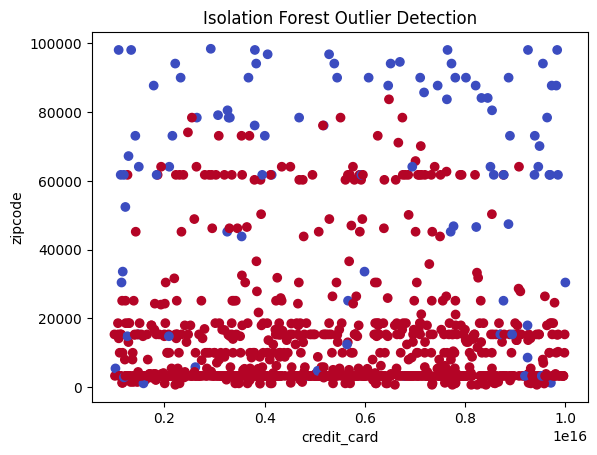

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

#나눔 고딕 적용
font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))

fontprop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = fontprop.get_name()


#데이터 가져오기
df = pd.read_csv("cc_info.csv")
print(df.head())

#자동 컬럼 선택
features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
X = df[features]

#학습
model = IsolationForest(n_estimators=1000, contamination=0.1, random_state=42)
model.fit(X)

#이상치 구분
df['anomaly'] = model.predict(X)


print(df['anomaly'].value_counts())


outliers = df[df['anomaly'] == -1]
print("Detected outliers:")
print(outliers)

#시각화
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df['anomaly'], cmap='coolwarm')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Isolation Forest Outlier Detection")
plt.show()